#PRAKTIKUM SISTEM MULTIMEDIA PT(7)

Nama: Catherine V. Pang

NRP/Prodi: 2C22200008 Sains Data VI/A

Tanggal: Senin, 2 Juni 2025

Materi: Implementasi Huffman Coding untuk Teks Proklamasi NKRI

Rincian Aktivitas Tugas: pengelolaan dokumen digital



## Catatan Pengantar

Algoritma Huffman adalah teknik kompresi data yang bekerja dengan prinsip **pengkodean berbasis frekuensi**. Berikut adalah langkah-langkah utamanya:

### 1. Menghitung Frekuensi Simbol  
Setiap simbol dalam data diberi nilai frekuensi yang menunjukkan seberapa sering simbol tersebut muncul.

### 2. Membangun Pohon Huffman  
- Buat **node** untuk setiap simbol dengan frekuensinya.
- Masukkan semua node ke dalam **heap** atau **priority queue** (struktur data yang selalu menyimpan elemen dengan frekuensi terendah di posisi teratas).
- Gabungkan dua node dengan **frekuensi terkecil** menjadi satu **node baru**, dengan frekuensi yang merupakan jumlah dari dua node tersebut.
- Ulangi proses ini hingga hanya ada satu node tersisa, yang menjadi **akar pohon Huffman**.

### 3. Menentukan Kode Huffman  
- Tetapkan **0** untuk cabang kiri dan **1** untuk cabang kanan di setiap pembagian pohon.
- Setiap simbol mendapatkan kode berdasarkan jalur dari akar ke daun (misalnya, "A" mungkin dikodekan sebagai **110**, sementara "B" sebagai **10**).

### 4. Mengompresi Data  
Gunakan kode Huffman yang sudah dibuat untuk mengonversi data asli ke bentuk biner yang lebih efisien.

### 5. Dekompresi Data  
Untuk membaca kembali data yang dikompresi, cukup gunakan pohon Huffman dan telusuri kode biner dari atas ke bawah hingga menemukan simbol yang sesuai.

Teknik ini sangat **efisien**, terutama untuk data yang memiliki pola kemunculan simbol yang tidak merata.


Huffman Coding adalah salah satu algoritma kompresi lossless yang paling mendasar dan banyak digunakan sebagai building block dalam kompresi multimedia.

* JPEG (gambar): Huffman Coding digunakan pada tahap akhir kompresi gambar setelah transformasi DCT dan kuantisasi.
* MP3 (audio): Menggunakan Huffman Coding untuk mengompresi data setelah analisis frekuensi.
* MPEG (video): Sama seperti JPEG, MPEG juga menggunakan Huffman Coding untuk efisiensi bitstream.

Dalam Sistem Multimedia diajarkan dua jenis kompresi:

* Lossless: data bisa dikembalikan 100% ke bentuk aslinya.
* Lossy: data dikompresi dengan membuang informasi yang dianggap kurang penting.

Huffman Coding adalah dasar dari kompresi lossless, dan penting untuk memahami bagaimana simbol (misal: karakter teks, blok piksel, atau koefisien frekuensi) bisa di-encode dengan efisien.



* Entropy (dalam informasi): ukuran rata-rata jumlah bit yang diperlukan untuk menyimpan simbol.
* Redundansi: informasi berulang yang bisa dihilangkan agar data lebih ringkas.

Huffman Coding bertujuan meminimalkan panjang rata-rata bit per simbol dengan membangun pohon optimal berdasarkan frekuensi

# Implementasi Huffman Coding pada Teks Proklamasi Indonesia
[referensi](https://informatika.stei.itb.ac.id/~rinaldi.munir/Matdis/2023-2024/Makalah2023/Makalah-Matdis-2023%20(37).pdf)

In [1]:
text = (
    "PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. "
    "Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara "
    "saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 "
    "tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta."
)
print(f"Panjang karakter teks: {len(text)}")


Panjang karakter teks: 290


In [2]:
from collections import Counter

frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

print("Karakter | Frekuensi")
for char, freq in frequencies.items():
    print(f"{repr(char):>8} | {freq}")


Karakter | Frekuensi
     'a' | 51
     ' ' | 34
     'n' | 33
     'e' | 21
     's' | 13
     'i' | 12
     'g' | 11
     'd' | 11
     'k' | 11
     't' | 10
     'm' | 9
     'o' | 9
     '.' | 8
     'l' | 7
     'r' | 6
     'j' | 5
     'I' | 4
     'h' | 4
     'A' | 3
     'b' | 3
     'K' | 2
     'S' | 2
     'H' | 2
     '-' | 2
     'p' | 2
     ',' | 2
     'P' | 1
     'R' | 1
     'O' | 1
     'L' | 1
     'M' | 1
     'y' | 1
     'D' | 1
     '1' | 1
     '7' | 1
     '8' | 1
     '0' | 1
     '5' | 1
     '/' | 1


In [3]:
import heapq

class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(frequencies):
    heap = [Node(char, freq) for char, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

tree = build_huffman_tree(frequencies)


In [4]:
def build_codes(node, prefix="", code_map={}):
    if node is not None:
        if node.char is not None:
            code_map[node.char] = prefix
        build_codes(node.left, prefix + "0", code_map)
        build_codes(node.right, prefix + "1", code_map)
    return code_map

huffman_codes = build_codes(tree)
print("Karakter | Kode Huffman")
for char, code in sorted(huffman_codes.items(), key=lambda x: len(x[1])):
    print(f"{repr(char):>8} | {code}")


Karakter | Kode Huffman
     'n' | 010
     ' ' | 100
     'a' | 111
     'i' | 0000
     's' | 0001
     'e' | 1011
     'r' | 00100
     'l' | 00101
     '.' | 00111
     'o' | 01110
     'm' | 01111
     't' | 10101
     'd' | 11001
     'g' | 11010
     'k' | 11011
     'h' | 001100
     'I' | 001101
     'j' | 110000
     'p' | 0110000
     '-' | 0110001
     'H' | 0110011
     'S' | 0110100
     'K' | 0110101
     'A' | 1010011
     'b' | 1100011
     '1' | 01100100
     'D' | 01100101
     'P' | 01101100
     '/' | 01101101
     '8' | 01101110
     '7' | 01101111
     'M' | 10100000
     'L' | 10100001
     'O' | 10100010
     'R' | 10100011
     '5' | 10100100
     '0' | 10100101
     'y' | 11000100
     ',' | 11000101


In [5]:
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")


Panjang teks setelah dikodekan dengan Huffman: 1258 bit


In [6]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 2320 bit

Kode biner ASCII :
01010000010100100100111101001011010011000100000101001101010000010101001101001001
00100000010010110110000101101101011010010010000001100010011000010110111001100111
01110011011000010010000001001001011011100110010001101111011011100110010101110011
01101001011000010010000001100100011001010110111001100111011000010110111000100000
01101001011011100110100100100000011011010110010101101110011010100110000101110100
01100001011010110110000101101110001000000110101101100101011011010110010101110010
01100100011001010110101101100001011000010110111000100000010010010110111001100100
01101111011011100110010101110011011010010110000100101110001000000100100001100001
01101100001011010110100001100001011011000010000001111001011000010110111001100111
00100000011011010110010101101110011001110110010101101110011000010110100100100000
01110000011001010110110101101001011011100110010001100001011010000110000101101110
00100000011010110110010101101011011011110110010101100001011100110

In [7]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Hasil Kode Biner:")
for i, line in enumerate(lines):
    print(line)

Panjang ASCII: 2320 bit

Hasil Kode Biner:
01010000010100100100111101001011010011000100000101001101010000010101001101001001
00100000010010110110000101101101011010010010000001100010011000010110111001100111
01110011011000010010000001001001011011100110010001101111011011100110010101110011
01101001011000010010000001100100011001010110111001100111011000010110111000100000
01101001011011100110100100100000011011010110010101101110011010100110000101110100
01100001011010110110000101101110001000000110101101100101011011010110010101110010
01100100011001010110101101100001011000010110111000100000010010010110111001100100
01101111011011100110010101110011011010010110000100101110001000000100100001100001
01101100001011010110100001100001011011000010000001111001011000010110111001100111
00100000011011010110010101101110011001110110010101101110011000010110100100100000
01110000011001010110110101101001011011100110010001100001011010000110000101101110
001000000110101101100101011010110110111101100101011000010111001101

In [8]:
encoded_text = ''.join(huffman_codes[char] for char in text)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

NameError: name 'ascii_bits' is not defined

In [9]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 1258 bit

Hasil encoding Huffman:
01101100101000111010001001101011010000110100111010000010100110110100001101100011
01011110111100001001100011111010110100001111100001101010110010111001010110001000
01111001100110110101101011101010000000100000100011111011010110000111101011111101
11110101001101110110111110110010011001101111011111111010100001101010110010111001
01011000100001110011110001100111110010101100010011001110010110011000100111010110
10100011111011010110101011010111000010001100001011011110000010110011110011001110
10100110111011110110111010111110001111111010100110010011100101001110010100111110
00101100110010000000110110010110110101101011010111001001111101111101010011001101
10101101011101010010101110000111001001111000001111110110001111011111111001100111
10101001100111100101111011111001010110110111101100000111010011000011101011010100
00011011000100000101101011011111101010110001000100000101101011011111101010101100
001110011110001100101110000111110111110010010101111110001011

In [10]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")


Dekode berhasil, teks asli dikembalikan dengan sempurna.


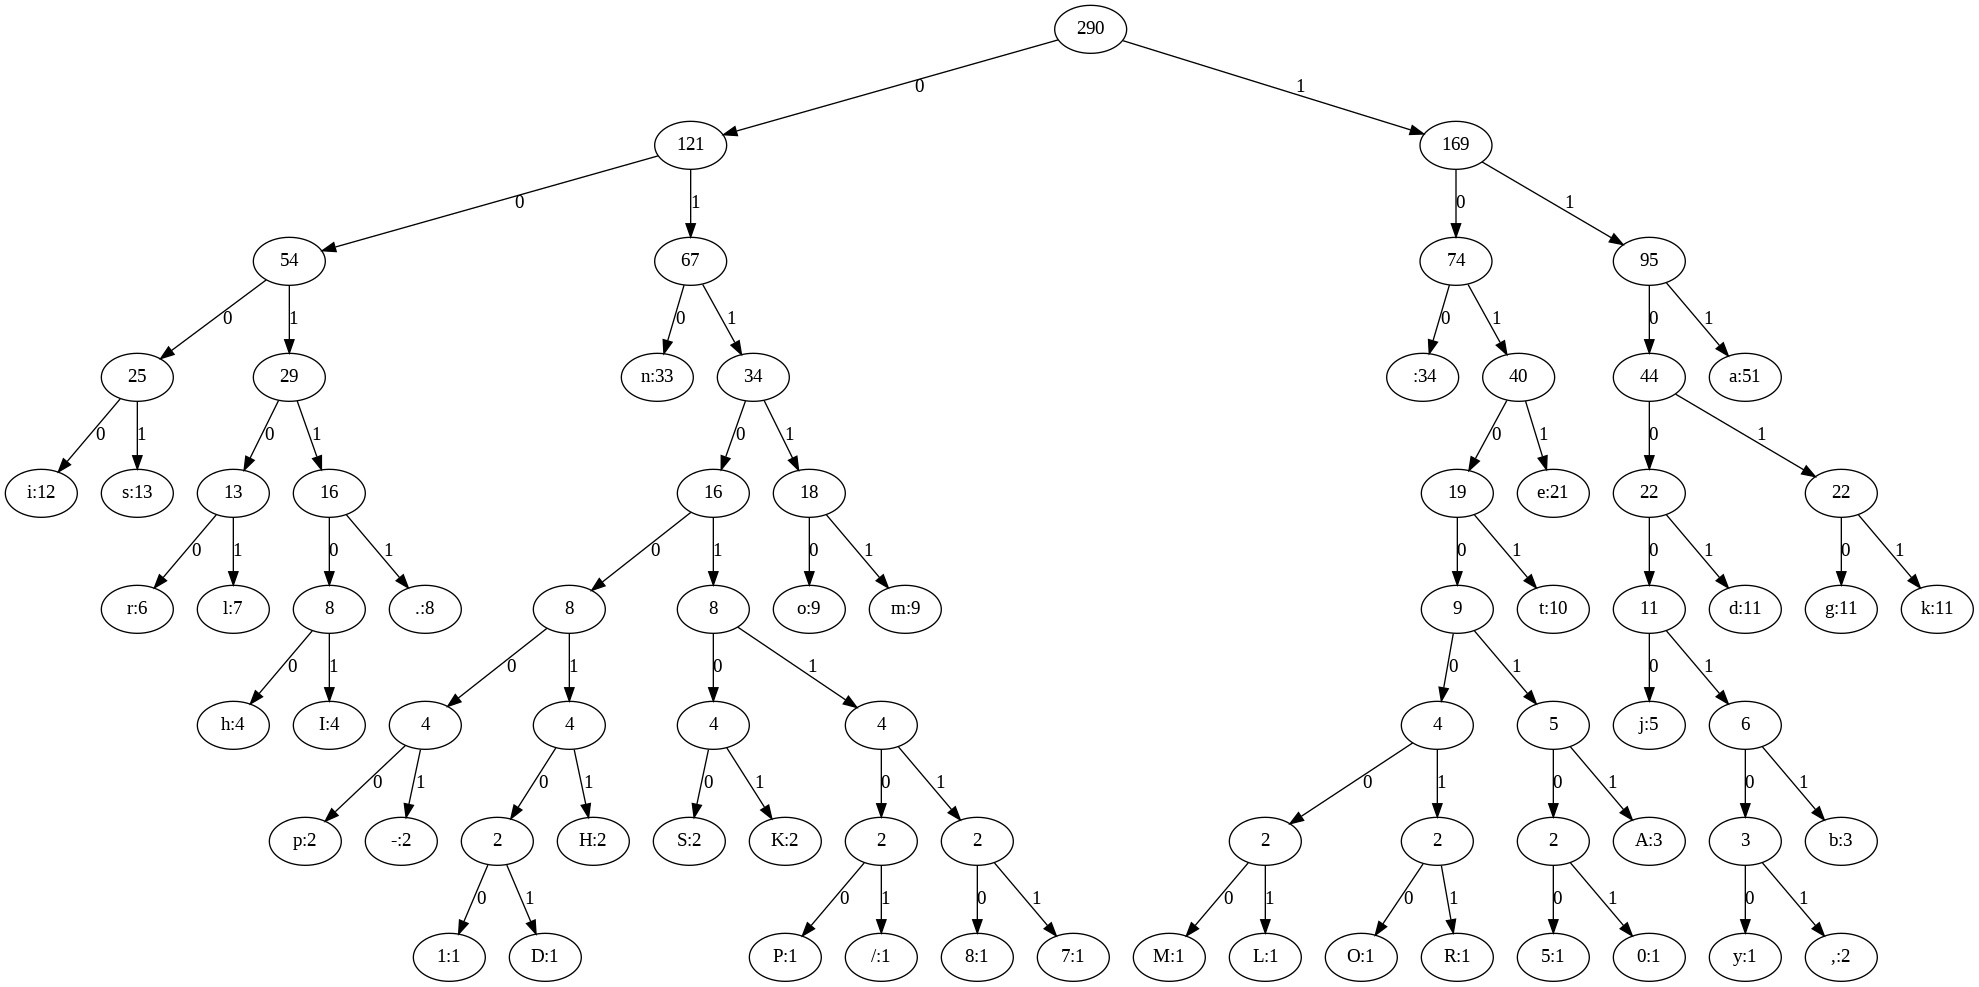

In [11]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")


## Eksperimen

1. Bandingkan Rasio Kompresi:
  * Teks dengan banyak karakter unik (misalnya paragraf acak).
  * Teks dengan karakter berulang (misalnya 'aaaaabbbbcccc').
  * Teks dengan distribusi karakter seragam vs tidak seragam.

  panjang teks tidak harus sama dengan panjang teks Proklamasi. Menggunakan berbagai panjang dan karakteristik teks bisa membantu Anda memahami kapan Huffman Coding efektif dan kapan tidak.

2. Modifikasi Jumlah Karakter:
  * Menambahkan atau menghapus karakter tertentu dari teks,
  * Lalu analisis perubahan pada struktur pohon, kode Huffman, dan hasil kompresi.

3. Validasi Konsistensi Decoding

  * Tambahkan kode error: ubah 1 bit pada hasil kompresi dan lihat apakah hasil decoding masih valid.

4. Ubah kode visualisasi untuk:
  * Menambahkan warna untuk daun vs simpul internal,
  * Menampilkan bit kode Huffman langsung di simpul daun.


#Pengerjaan Tugas

## **Eksperimen 1: Bandingkan Rasio Kompresi**

### 1a. Teks Banyak Karakter Unik

In [23]:
text = (
    "PROKL4MAS! K4m1 b4n9s4 Ind0n3s!a d3n94n !n! m3nj4t4kan k3m3rd3k4an Indon3s14. "
    "H4l-hal y4n9 m3n9ena1 p3m!nd4han k3k0e4s44n dll, d1s3len99ar4kan d3n9an tj4ra "
    "saks4m4 d@n d@lam t3mp0 j@ng s3singkat-singk@tnja. Dj@kart4, h@ri 17 bo3l@n 8 "
    "tah03n 05. At@s n4ma b4ngsa Indones1a. S03k4rn0/H@tt@."
)
print(f"Panjang karakter teks: {len(text)}")


Panjang karakter teks: 288


In [24]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)


In [25]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 1358 bit


In [26]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 2304 bit

Kode biner ASCII :
01010000010100100100111101001011010011000011010001001101010000010101001100100001
00100000010010110011010001101101001100010010000001100010001101000110111000111001
01110011001101000010000001001001011011100110010000110000011011100011001101110011
00100001011000010010000001100100001100110110111000111001001101000110111000100000
00100001011011100010000100100000011011010011001101101110011010100011010001110100
00110100011010110110000101101110001000000110101100110011011011010011001101110010
01100100001100110110101100110100011000010110111000100000010010010110111001100100
01101111011011100011001101110011001100010011010000101110001000000100100000110100
01101100001011010110100001100001011011000010000001111001001101000110111000111001
00100000011011010011001101101110001110010110010101101110011000010011000100100000
01110000001100110110110100100001011011100110010000110100011010000110000101101110
00100000011010110011001101101011001100000110010100110100011100110

In [27]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 1358 bit

Hasil encoding Huffman:
11111110001100010011000000111011011000111101011000000111000111001101101100001110
11110011111111101001111110111001000100000011101001111011010110100001101001100000
10110110101001101001100100010011100101001011010101011011000111101100101100011110
10111111011011101001010011011011001111011011110011010011011011111010100101001111
01101011010111101001001100000111110111011000010001110001110000101111111101110110
10000101000010100111100100010010001111011001000100001111010101011111010000110010
11001111101101010110101110011101101001010011011011011011000110011111110000011101
11001010011010000100001000101011001101011111000000110000100011110100010000100101
01111001110110111010010100110100110010001001010010100101111100011110111100101010
00000101011011000011100111111101001101011001010100110101100100010101001111100101
11011001111001100100011100110001110010100011011000000011000001011001010001101110
111010101111111111100001011001010001101110111100110111010110

In [28]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


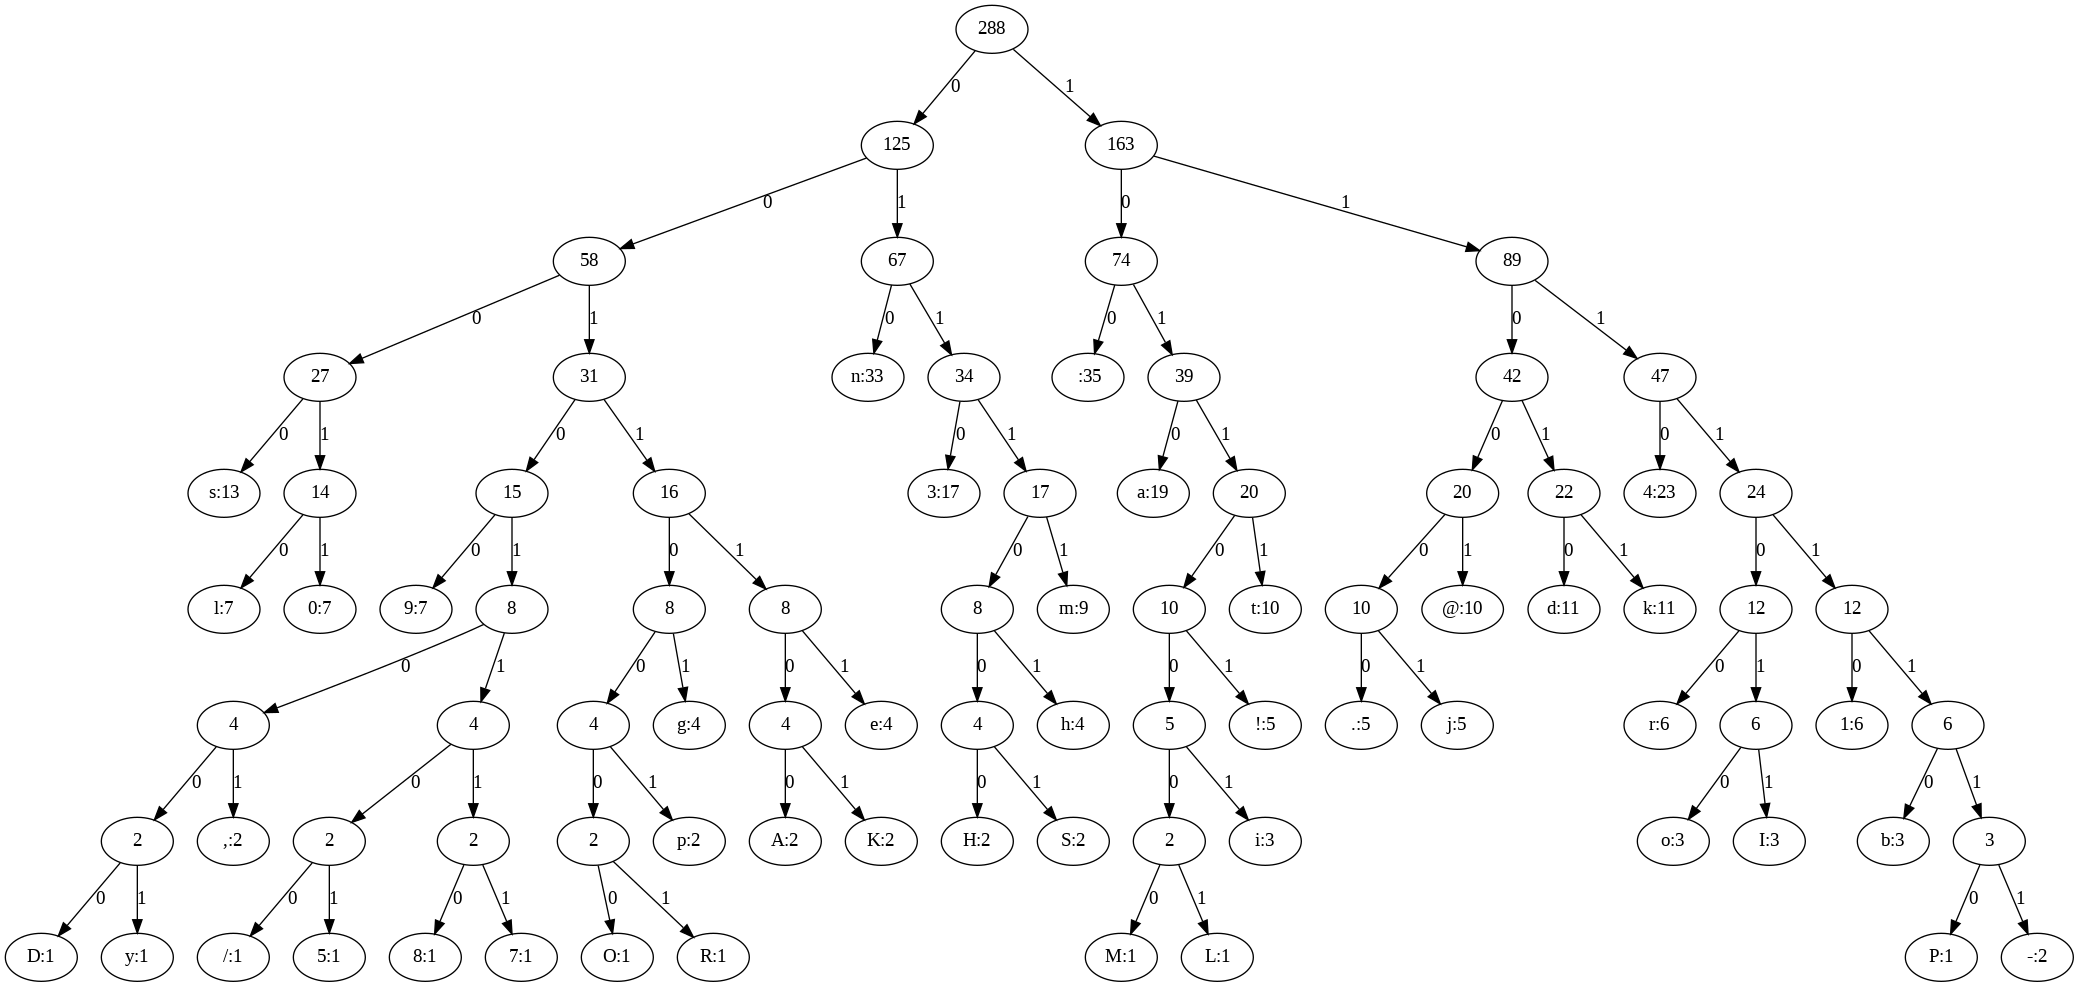

In [29]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

###1.b. Teks dengan Karakter Berulang

In [30]:
text = (
    "PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP"
    "RRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR"
    "OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO"
    "KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK"
    "LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL"
    "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA"
    "MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM"
    "SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS"
)
print(f"Panjang karakter teks: {len(text)}")

Panjang karakter teks: 576


In [31]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)

In [32]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 1728 bit


In [33]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 4608 bit

Kode biner ASCII :
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101000001010000010100000101000001010000010100000101000001010000
01010000010100000101001001010010010100100101001001010010010100100101001001010010
01010010010100100101001001010010010100100101001001010010010100100101001001010010
01010010010100100101001001010010010100100101001001010010010100100101001001010010
01010010010100100101001001010010010100100101001001010010010100100101001001010010
01010010010100100101001001010010010100100101001001010010010100100

In [34]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 1728 bit

Hasil encoding Huffman:
10010010010010010010010010010010010010010010010010010010010010010010010010010010
01001001001001001001001001001001001001001001001001001001001001001001001001001001
00100100100100100100100100100100100100100100100100100100110110110110110110110110
11011011011011011011011011011011011011011011011011011011011011011011011011011011
01101101101101101101101101101101101101101101101101101101101101101101101101101101
10110110110110110110110110110110001001001001001001001001001001001001001001001001
00100100100100100100100100100100100100100100100100100100100100100100100100100100
10010010010010010010010010010010010010010010010010010010010010010010010010010010
01001001010010010010010010010010010010010010010010010010010010010010010010010010
01001001001001001001001001001001001001001001001001001001001001001001001001001001
00100100100100100100100100100100100100100100100100100100100100100110110110110110
110110110110110110110110110110110110110110110110110110110110

In [35]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


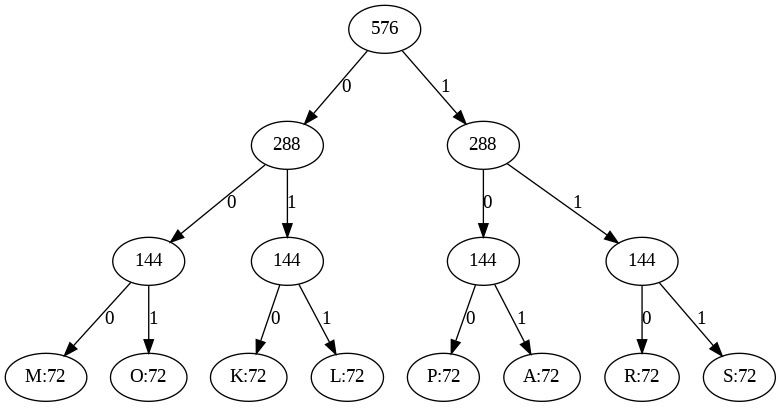

In [36]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

###1c. Teks dengan Distribusi Seragam

In [37]:
text = (
    "abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+"
    "abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+"
    "abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+"
    "abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+"
)
print(f"Panjang karakter teks: {len(text)}")

Panjang karakter teks: 328


In [38]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)

In [39]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 2048 bit


In [40]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 2624 bit

Kode biner ASCII :
01100001011000100110001101100100011001010110011001100111011010000110100100100000
01101010011010110110110001101101011011100110111101110000001000000111000101110010
01110011011101000111010101110110011101110111100001111001011110100010000001000001
01000010010000110100010001000101010001100100011101001000010010010100101001001011
01001100010011010100111001001111010100000010000001010001010100100101001101010100
01010101010101100101011101011000010110010101101000110000001100010011001000110011
00100000001101000011010100110110001101110011100000111001001000000010000101000000
00100011001001000010010101011110001001100010101000101000001010010010110101011111
00111101001010110110000101100010011000110110010001100101011001100110011101101000
01101001001000000110101001101011011011000110110101101110011011110111000000100000
01110001011100100111001101110100011101010111011001110111011110000111100101111010
00100000010000010100001001000011010001000100010101000110010001110

In [41]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 2048 bit

Hasil encoding Huffman:
01011100110001001001011011110111110011100011000011101010101111001111110110111101
01101010111001010000101110110111101110000010110010111000011010001100110100111000
00110010011010011011100000000111111010011100011111000001110011001011100000101001
00111111100100010100001100100101011110000010111010010010110010100101010101001001
10111011100000010010101101101101011010001100010011111101101100000011000010011011
11001101111000010111111001001111110001111111010111101111100110101111011011000101
10110011101010010001111111010011010111001100010010010110111101111100111000110000
11101010101111001111110110111101011010101110010100001011101101111011100000101100
10111000011010001100110100111000001100100110100110111000000001111110100111000111
11000001110011001011100000101001001111111001000101000011001001010111100000101110
10010010110010100101010101001001101110111000000100101011011011010110100011000100
111111011011000000110000100110111100110111100001011111100100

In [42]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


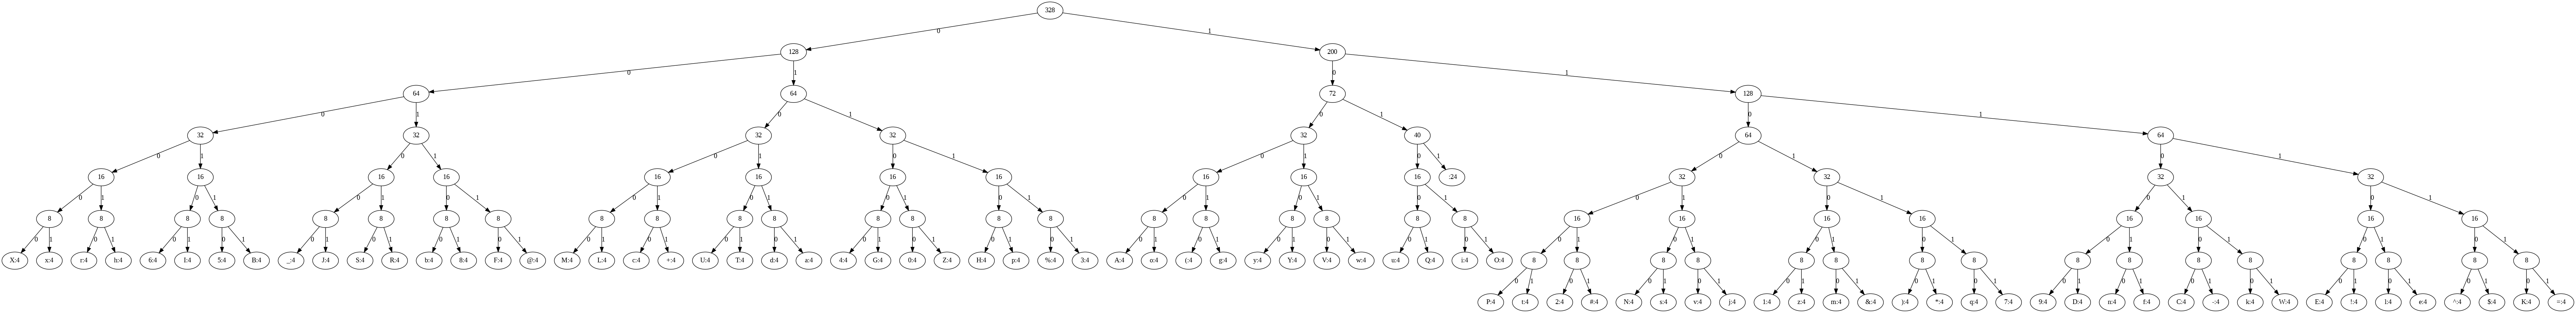

In [43]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

###1d. Teks dengan Distribusi Tidak Seragam

In [44]:
text = (
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee"
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee"
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee"
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee"
)
print(f"Panjang karakter teks: {len(text)}")

Panjang karakter teks: 260


In [45]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)

In [46]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 404 bit


In [47]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 2080 bit

Kode biner ASCII :
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000100110001001100010011000100110001001100010
01100010011000100110001001100010011000110110001101100011011000110110001101100011
01100011011001000110010001100101011001010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100001
01100001011000010110000101100001011000010110000101100001011000010110000101100010
01100010011000100110001001100010011000100110001001100010011000100

In [48]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 404 bit

Hasil encoding Huffman:
11111111111111111111111111111111111111111111000000000000000000000110110110110110
11011010101010100010011111111111111111111111111111111111111111111000000000000000
00000011011011011011011011010101010100010011111111111111111111111111111111111111
11111100000000000000000000011011011011011011011010101010100010011111111111111111
11111111111111111111111111100000000000000000000011011011011011011011010101010100
0100


Efisiensi Kompresi: 80.58%


In [49]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


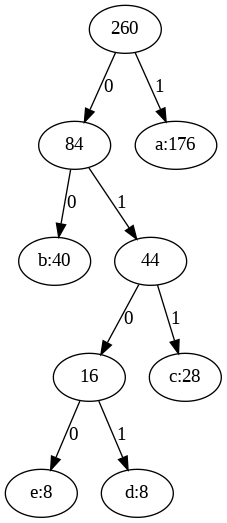

In [50]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

###Fungsi Perbandingan Hasil Kompresi 1.a. hingga 1.d.

In [53]:
def compare_compression(text_list):
    results = {}
    for i, text_data in enumerate(text_list):
        text = text_data["text"]
        name = text_data["name"]

        print(f"--- Analisis untuk: {name} ---")
        print(f"Panjang karakter teks asli: {len(text)}")

        # Calculate frequencies
        frequencies = Counter(text)
        frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

        # Build Huffman tree
        tree = build_huffman_tree(frequencies)

        # Generate Huffman codes
        huffman_codes = build_codes(tree)

        # Encode the text
        encoded_text = ''.join(huffman_codes[char] for char in text)
        print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

        # Calculate ASCII binary length
        ascii_binary = ''.join(format(ord(char), '08b') for char in text)
        ascii_bits = len(ascii_binary)
        print(f"Panjang teks asli (ASCII): {ascii_bits} bit")

        # Calculate compression ratio
        if ascii_bits > 0:
            compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100
        else:
            compression_ratio = 0 # Handle empty text case

        print(f"Efisiensi Kompresi: {compression_ratio:.2f}%\n")

        # Store results
        results[name] = {
            "original_length_chars": len(text),
            "original_length_bits_ascii": ascii_bits,
            "compressed_length_bits_huffman": len(encoded_text),
            "compression_ratio": compression_ratio
        }
    return results

# Define the text samples for comparison
text_samples = [
    {"name": "1a. Teks Banyak Karakter Unik", "text": "PROKL4MAS! K4m1 b4n9s4 Ind0n3s!a d3n94n !n! m3nj4t4kan k3m3rd3k4an Indon3s14. H4l-hal y4n9 m3n9ena1 p3m!nd4han k3k0e4s44n dll, d1s3len99ar4kan d3n9an tj4ra saks4m4 d@n d@lam t3mp0 j@ng s3singkat-singk@tnja. Dj@kart4, h@ri 17 bo3l@n 8 tah03n 05. At@s n4ma b4ngsa Indones1a. S03k4rn0/H@tt@."},
    {"name": "1b. Teks dengan Karakter Berulang", "text": "PPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPPP RRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRRR OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS"},
    {"name": "1c. Teks dengan Distribusi Seragam", "text": "abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+ abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+ abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+ abcdefghi jklmnop qrstuvwxyz ABCDEFGHIJKLMNOP QRSTUVWXYZ0123 456789 !@#$%^&*()-_=+"},
    {"name": "1d. Teks dengan Distribusi Tidak Seragam", "text": "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbcccccccddee"}
]

# Run the comparison
compression_results = compare_compression(text_samples)

# Print a summary table
print("--- Ringkasan Hasil Kompresi Huffman ---")
print("{:<30} | {:<20} | {:<20} | {:<20} | {:<18}".format(
    "Nama Teks", "Panjang Asli (kar)", "Panjang Asli (bit)", "Panjang Kompresi (bit)", "Rasio Kompresi (%)"))
print("-" * 120)
for name, data in compression_results.items():
    print("{:<30} | {:<20} | {:<20} | {:<20} | {:<18.2f}".format(
        name, data["original_length_chars"], data["original_length_bits_ascii"],
        data["compressed_length_bits_huffman"], data["compression_ratio"]))


--- Analisis untuk: 1a. Teks Banyak Karakter Unik ---
Panjang karakter teks asli: 288
Panjang teks setelah dikodekan dengan Huffman: 1358 bit
Panjang teks asli (ASCII): 2304 bit
Efisiensi Kompresi: 41.06%

--- Analisis untuk: 1b. Teks dengan Karakter Berulang ---
Panjang karakter teks asli: 583
Panjang teks setelah dikodekan dengan Huffman: 1828 bit
Panjang teks asli (ASCII): 4664 bit
Efisiensi Kompresi: 60.81%

--- Analisis untuk: 1c. Teks dengan Distribusi Seragam ---
Panjang karakter teks asli: 331
Panjang teks setelah dikodekan dengan Huffman: 2060 bit
Panjang teks asli (ASCII): 2648 bit
Efisiensi Kompresi: 22.21%

--- Analisis untuk: 1d. Teks dengan Distribusi Tidak Seragam ---
Panjang karakter teks asli: 266
Panjang teks setelah dikodekan dengan Huffman: 430 bit
Panjang teks asli (ASCII): 2128 bit
Efisiensi Kompresi: 79.79%

--- Ringkasan Hasil Kompresi Huffman ---
Nama Teks                      | Panjang Asli (kar)   | Panjang Asli (bit)   | Panjang Kompresi (bit) | Rasio Kompre

## **Eksperimen 2: Modifikasi Jumlah Karakter**

### 2.a. Mengurangi Karakter

In [54]:
text = (
    "PROKLMSI Kmi bngs Indonesi dengn ini menjtkn kemerdekn Indonesi "
    "Hl-hl yng mengeni pemindhn kekoesn dll, diselenggrkn dengn tjr "
    "sksm dn dlm tempo jng sesingkt-singktnj Djkrt, hri 17 boeln 8 "
    "thoen 05 ts nm bngs IndonesiSoekrno/Htt" #menghilangkan huruf A, a dan "."
)
print(f"Panjang karakter teks: {len(text)}")

Panjang karakter teks: 228


In [55]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)

In [56]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 987 bit


In [57]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 1824 bit

Kode biner ASCII :
01010000010100100100111101001011010011000100110101010011010010010010000001001011
01101101011010010010000001100010011011100110011101110011001000000100100101101110
01100100011011110110111001100101011100110110100100100000011001000110010101101110
01100111011011100010000001101001011011100110100100100000011011010110010101101110
01101010011101000110101101101110001000000110101101100101011011010110010101110010
01100100011001010110101101101110001000000100100101101110011001000110111101101110
01100101011100110110100100100000010010000110110000101101011010000110110000100000
01111001011011100110011100100000011011010110010101101110011001110110010101101110
01101001001000000111000001100101011011010110100101101110011001000110100001101110
00100000011010110110010101101011011011110110010101110011011011100010000001100100
01101100011011000010110000100000011001000110100101110011011001010110110001100101
01101110011001110110011101110010011010110110111000100000011001000

In [58]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 987 bit

Hasil encoding Huffman:
11111101111111001000110110010001000110011111111110011110110111101001000111010101
11001101010100100111110011011101001111100101000011101011100011000101001010111001
01101010111011101000101111110111100100101110010000011101000011000011000010010111
00110111010011111001010000111010111010011101000010011011001011000011011111111010
10010110111010001010010000101010111010011000001110101011010011100101101110010000
00100111000000111101110001110000100001000111110001101010111000100000001010010001
00110001001011100011000101001010111011110111110011001100111010001111110111000111
01110001110000111011101111000011101100110011100110111110101001011001110000111010
11010010010011110100110101110101101001001001111010111111011010010011111110010001
10011110100011111010010101100010111010010010111111101100110101110000010000101110
10001011110111101001011110000010111010001010100010011101111001111101011110111001
1010101001001111100110111010011111001010000111010110011111110

In [59]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


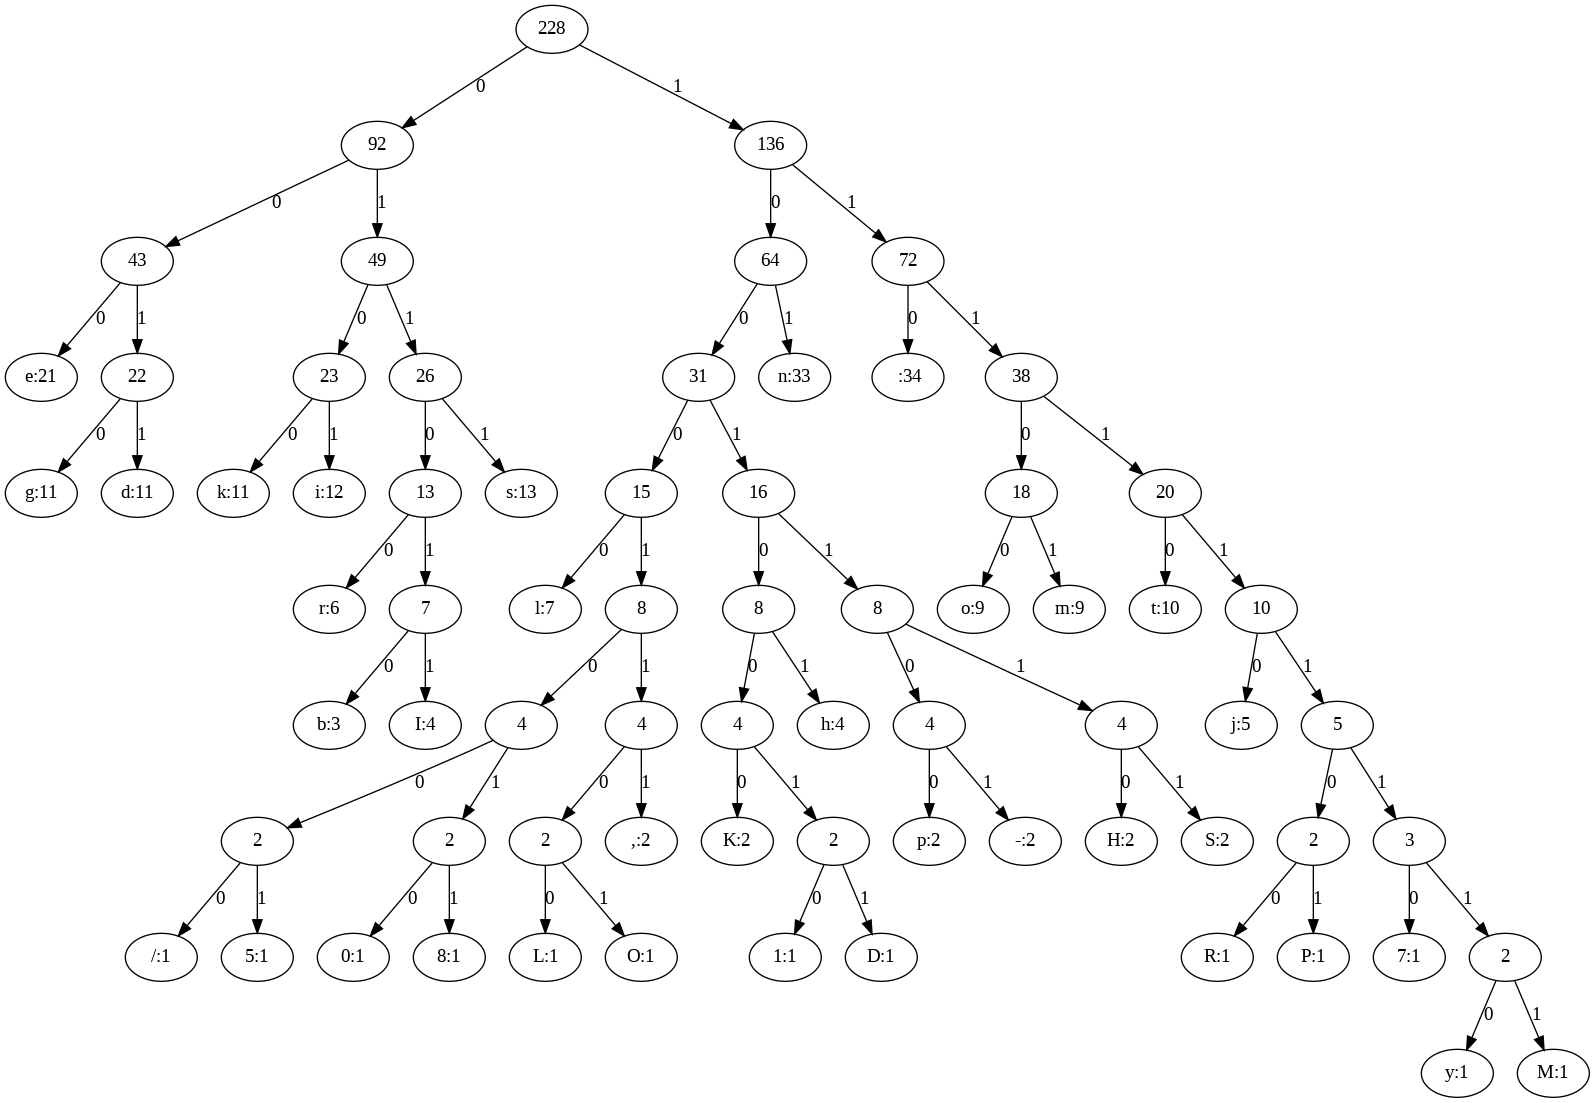

In [60]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

### 2.b. Menambahkan Karakter

In [61]:
text = (
    "PROKLAMASI Kamiz bangsaz Indonesiaz denganz iniz menjatakanz kemerdekaanz Indonesiaz. "
    "Hal-hal yangz mengenaiz pemindahanz kekoeasaanz d.l.l., diselenggarakan dengan tjara "
    "saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 "
    "tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta."
)
print(f"Panjang karakter teks: {len(text)}")


Panjang karakter teks: 302


In [63]:

from collections import Counter

# Rebuild the frequencies for the new text
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

# Rebuild the Huffman tree based on the new frequencies
tree = build_huffman_tree(frequencies)

# Generate new Huffman codes from the new tree
huffman_codes = build_codes(tree)

In [64]:

# Now encode the text using the new huffman_codes
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"Panjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")

Panjang teks setelah dikodekan dengan Huffman: 1330 bit


In [65]:
ascii_binary = ''.join(format(ord(char), '08b') for char in text)

n = 80
lines = [ascii_binary[i:i+n] for i in range(0, len(ascii_binary), n)]

print(f"Panjang ASCII: {len(ascii_binary)} bit\n")
print("Kode biner ASCII :")
for i, line in enumerate(lines):
    print(f"{line}")

Panjang ASCII: 2416 bit

Kode biner ASCII :
01010000010100100100111101001011010011000100000101001101010000010101001101001001
00100000010010110110000101101101011010010111101000100000011000100110000101101110
01100111011100110110000101111010001000000100100101101110011001000110111101101110
01100101011100110110100101100001011110100010000001100100011001010110111001100111
01100001011011100111101000100000011010010110111001101001011110100010000001101101
01100101011011100110101001100001011101000110000101101011011000010110111001111010
00100000011010110110010101101101011001010111001001100100011001010110101101100001
01100001011011100111101000100000010010010110111001100100011011110110111001100101
01110011011010010110000101111010001011100010000001001000011000010110110000101101
01101000011000010110110000100000011110010110000101101110011001110111101000100000
01101101011001010110111001100111011001010110111001100001011010010111101000100000
01110000011001010110110101101001011011100110010001100001011010000

In [66]:
encoded_text = ''.join(huffman_codes[char] for char in text)

# Calculate the number of bits in the ASCII representation
ascii_bits = len(ascii_binary)
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

n = 80
lines = [encoded_text[i:i+n] for i in range(0, len(encoded_text), n)]

print(f"Panjang ASCII: {len(encoded_text)} bit\n")
print("Hasil encoding Huffman:")
for i, line in enumerate(lines):
    print(line)

print ("\n")
print(f"Efisiensi Kompresi: {compression_ratio:.2f}%")

Panjang ASCII: 1330 bit

Hasil encoding Huffman:
00101111001011100010110100100110010110011001111100101011001110010010100010011001
00111111000011010110110111100110111010101100001111110110111000100101100010010010
10100001110101111101101111000101001010110111010110110111101001011010110110111000
01010010100011111100111111011111101011011011101111010100001010000001100010101011
11111110101101101110001001011000100100101010000111010111110110011101100100001110
00010011011001100111000010110010001111101010110110110111000010100101011010100101
11110101101101100110101010100001101001011000111001100111010110110111011110101011
11001010101110001111111010110110111100000111000010011100001001111100101101111000
11010000110100000110100101011010110111000001111011111101001111000101001010110111
01001110011100011111000001110110001111101110001111100001110111100011101001111000
11100001111100000111001110101000000110101001001110001111101010110011000110100001
110100101011010111111100110011011000111010010101101011111110

In [67]:
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("Dekode berhasil, teks asli dikembalikan dengan sempurna.")

Dekode berhasil, teks asli dikembalikan dengan sempurna.


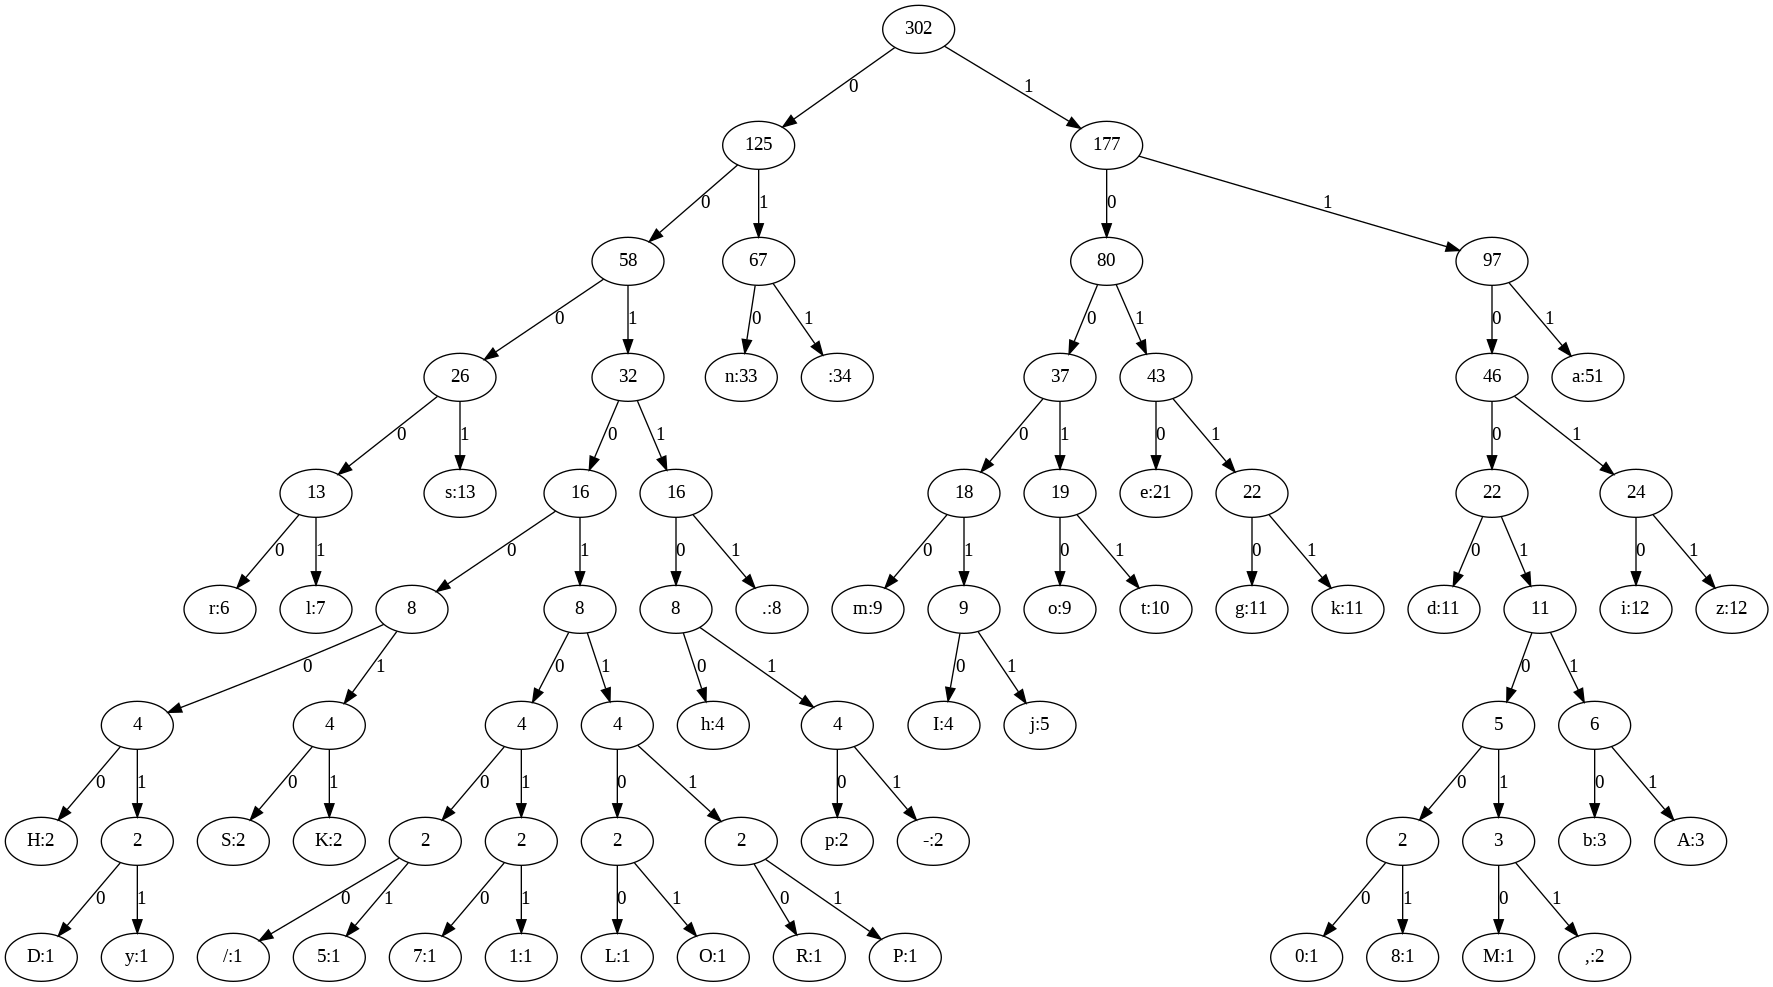

In [68]:
from graphviz import Digraph

def visualize_huffman_tree(node):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        label = f"{node.char}:{node.freq}" if node.char else f"{node.freq}"
        dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

visual_tree = visualize_huffman_tree(tree)
visual_tree.render("huffman_tree", format="png", cleanup=True)
from IPython.display import Image
Image("huffman_tree.png")

## **Eksperimen 3 Validasi Konsistensi Decoding**

In [69]:
from collections import Counter
import heapq
import random

text = (
    "PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. "
    "Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara "
    "saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 "
    "tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta."
)
print(f"Panjang karakter teks: {len(text)}")


Panjang karakter teks: 290


In [70]:

# Hitung frekuensi karakter
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

print("\nKarakter | Frekuensi")
for char, freq in frequencies.items():
    print(f"{repr(char):>8} | {freq}")


Karakter | Frekuensi
     'a' | 51
     ' ' | 34
     'n' | 33
     'e' | 21
     's' | 13
     'i' | 12
     'g' | 11
     'd' | 11
     'k' | 11
     't' | 10
     'm' | 9
     'o' | 9
     '.' | 8
     'l' | 7
     'r' | 6
     'j' | 5
     'I' | 4
     'h' | 4
     'A' | 3
     'b' | 3
     'K' | 2
     'S' | 2
     'H' | 2
     '-' | 2
     'p' | 2
     ',' | 2
     'P' | 1
     'R' | 1
     'O' | 1
     'L' | 1
     'M' | 1
     'y' | 1
     'D' | 1
     '1' | 1
     '7' | 1
     '8' | 1
     '0' | 1
     '5' | 1
     '/' | 1


In [71]:
# Definisi kelas Node untuk pohon Huffman
class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq
# Fungsi membangun pohon Huffman
def build_huffman_tree(frequencies):
    heap = [Node(char, freq) for char, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

tree = build_huffman_tree(frequencies)

# Fungsi membangun kode Huffman
def build_codes(node, prefix="", code_map={}):
    if node is not None:
        if node.char is not None:
            code_map[node.char] = prefix
        build_codes(node.left, prefix + "0", code_map)
        build_codes(node.right, prefix + "1", code_map)
    return code_map

huffman_codes = build_codes(tree)

print("\nKarakter | Kode Huffman")
for char, code in sorted(huffman_codes.items(), key=lambda x: len(x[1])):
    print(f"{repr(char):>8} | {code}")



Karakter | Kode Huffman
     'n' | 010
     ' ' | 100
     'a' | 111
     'i' | 0000
     's' | 0001
     'e' | 1011
     'r' | 00100
     'l' | 00101
     '.' | 00111
     'o' | 01110
     'm' | 01111
     't' | 10101
     'd' | 11001
     'g' | 11010
     'k' | 11011
     'h' | 001100
     'I' | 001101
     'j' | 110000
     'p' | 0110000
     '-' | 0110001
     'H' | 0110011
     'S' | 0110100
     'K' | 0110101
     'A' | 1010011
     'b' | 1100011
     '1' | 01100100
     'D' | 01100101
     'P' | 01101100
     '/' | 01101101
     '8' | 01101110
     '7' | 01101111
     'M' | 10100000
     'L' | 10100001
     'O' | 10100010
     'R' | 10100011
     '5' | 10100100
     '0' | 10100101
     'y' | 11000100
     ',' | 11000101


In [72]:

# Proses encoding Huffman
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"\nPanjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")


Panjang teks setelah dikodekan dengan Huffman: 1258 bit


In [73]:

# Hitung panjang ASCII
ascii_binary = ''.join(format(ord(char), '08b') for char in text)
ascii_bits = len(ascii_binary)

print(f"\nPanjang ASCII: {ascii_bits} bit")
print("Hasil Kode Biner ASCII:")
for i in range(0, len(ascii_binary), 80):
    print(ascii_binary[i:i+80])


Panjang ASCII: 2320 bit
Hasil Kode Biner ASCII:
01010000010100100100111101001011010011000100000101001101010000010101001101001001
00100000010010110110000101101101011010010010000001100010011000010110111001100111
01110011011000010010000001001001011011100110010001101111011011100110010101110011
01101001011000010010000001100100011001010110111001100111011000010110111000100000
01101001011011100110100100100000011011010110010101101110011010100110000101110100
01100001011010110110000101101110001000000110101101100101011011010110010101110010
01100100011001010110101101100001011000010110111000100000010010010110111001100100
01101111011011100110010101110011011010010110000100101110001000000100100001100001
01101100001011010110100001100001011011000010000001111001011000010110111001100111
00100000011011010110010101101110011001110110010101101110011000010110100100100000
01110000011001010110110101101001011011100110010001100001011010000110000101101110
001000000110101101100101011010110110111101100101011000010111

In [74]:

# Hitung rasio kompresi
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

print(f"\nEfisiensi Kompresi: {compression_ratio:.2f}%")



Efisiensi Kompresi: 45.78%


In [75]:
# Fungsi untuk melakukan decoding Huffman
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("\nDekode berhasil, teks asli dikembalikan dengan sempurna.")



Dekode berhasil, teks asli dikembalikan dengan sempurna.


In [76]:
# Fungsi untuk menambahkan error dengan mengubah 1 bit
def introduce_error(encoded_text):
    encoded_list = list(encoded_text)
    index = random.randint(0, len(encoded_list) - 1)  # Pilih posisi acak
    encoded_list[index] = "1" if encoded_list[index] == "0" else "0"  # Flip bit
    return "".join(encoded_list)

# Simpan teks terkompresi asli
original_encoded = encoded_text

# Tambahkan error pada teks terkompresi
corrupted_encoded = introduce_error(original_encoded)

# Dekode teks yang sudah diberi error
corrupted_decoded_text = decode(corrupted_encoded, tree)


In [78]:

# Validasi konsistensi decoding
print("\n=== Validasi Konsistensi Decoding ===")
print("Apakah hasil decoding tetap valid?")
print("Hasil decoding dengan error:", corrupted_decoded_text)
print("Hasil decoding asli:", decoded_text)
print("Status validasi:", "Valid" if corrupted_decoded_text == text else "Tidak Valid")


=== Validasi Konsistensi Decoding ===
Apakah hasil decoding tetap valid?
Hasil decoding dengan error: PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerd amatigeldny.. Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta.
Hasil decoding asli: PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta.
Status validasi: Tidak Valid


## **Eksperimen 4 Visual Diubah**

In [79]:
from collections import Counter
import heapq
import random

text = (
    "PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. "
    "Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara "
    "saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 "
    "tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta."
)
print(f"Panjang karakter teks: {len(text)}")


Panjang karakter teks: 290


In [80]:

# Hitung frekuensi karakter
frequencies = Counter(text)
frequencies = dict(sorted(frequencies.items(), key=lambda x: x[1], reverse=True))

print("\nKarakter | Frekuensi")
for char, freq in frequencies.items():
    print(f"{repr(char):>8} | {freq}")


Karakter | Frekuensi
     'a' | 51
     ' ' | 34
     'n' | 33
     'e' | 21
     's' | 13
     'i' | 12
     'g' | 11
     'd' | 11
     'k' | 11
     't' | 10
     'm' | 9
     'o' | 9
     '.' | 8
     'l' | 7
     'r' | 6
     'j' | 5
     'I' | 4
     'h' | 4
     'A' | 3
     'b' | 3
     'K' | 2
     'S' | 2
     'H' | 2
     '-' | 2
     'p' | 2
     ',' | 2
     'P' | 1
     'R' | 1
     'O' | 1
     'L' | 1
     'M' | 1
     'y' | 1
     'D' | 1
     '1' | 1
     '7' | 1
     '8' | 1
     '0' | 1
     '5' | 1
     '/' | 1


In [81]:
# Definisi kelas Node untuk pohon Huffman
class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq
# Fungsi membangun pohon Huffman
def build_huffman_tree(frequencies):
    heap = [Node(char, freq) for char, freq in frequencies.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)
        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right
        heapq.heappush(heap, merged)

    return heap[0]

tree = build_huffman_tree(frequencies)

# Fungsi membangun kode Huffman
def build_codes(node, prefix="", code_map={}):
    if node is not None:
        if node.char is not None:
            code_map[node.char] = prefix
        build_codes(node.left, prefix + "0", code_map)
        build_codes(node.right, prefix + "1", code_map)
    return code_map

huffman_codes = build_codes(tree)

print("\nKarakter | Kode Huffman")
for char, code in sorted(huffman_codes.items(), key=lambda x: len(x[1])):
    print(f"{repr(char):>8} | {code}")



Karakter | Kode Huffman
     'n' | 010
     ' ' | 100
     'a' | 111
     'i' | 0000
     's' | 0001
     'e' | 1011
     'r' | 00100
     'l' | 00101
     '.' | 00111
     'o' | 01110
     'm' | 01111
     't' | 10101
     'd' | 11001
     'g' | 11010
     'k' | 11011
     'h' | 001100
     'I' | 001101
     'j' | 110000
     'p' | 0110000
     '-' | 0110001
     'H' | 0110011
     'S' | 0110100
     'K' | 0110101
     'A' | 1010011
     'b' | 1100011
     '1' | 01100100
     'D' | 01100101
     'P' | 01101100
     '/' | 01101101
     '8' | 01101110
     '7' | 01101111
     'M' | 10100000
     'L' | 10100001
     'O' | 10100010
     'R' | 10100011
     '5' | 10100100
     '0' | 10100101
     'y' | 11000100
     ',' | 11000101


In [82]:

# Proses encoding Huffman
encoded_text = ''.join(huffman_codes[char] for char in text)
print(f"\nPanjang teks setelah dikodekan dengan Huffman: {len(encoded_text)} bit")


Panjang teks setelah dikodekan dengan Huffman: 1258 bit


In [83]:

# Hitung panjang ASCII
ascii_binary = ''.join(format(ord(char), '08b') for char in text)
ascii_bits = len(ascii_binary)

print(f"\nPanjang ASCII: {ascii_bits} bit")
print("Hasil Kode Biner ASCII:")
for i in range(0, len(ascii_binary), 80):
    print(ascii_binary[i:i+80])


Panjang ASCII: 2320 bit
Hasil Kode Biner ASCII:
01010000010100100100111101001011010011000100000101001101010000010101001101001001
00100000010010110110000101101101011010010010000001100010011000010110111001100111
01110011011000010010000001001001011011100110010001101111011011100110010101110011
01101001011000010010000001100100011001010110111001100111011000010110111000100000
01101001011011100110100100100000011011010110010101101110011010100110000101110100
01100001011010110110000101101110001000000110101101100101011011010110010101110010
01100100011001010110101101100001011000010110111000100000010010010110111001100100
01101111011011100110010101110011011010010110000100101110001000000100100001100001
01101100001011010110100001100001011011000010000001111001011000010110111001100111
00100000011011010110010101101110011001110110010101101110011000010110100100100000
01110000011001010110110101101001011011100110010001100001011010000110000101101110
001000000110101101100101011010110110111101100101011000010111

In [84]:

# Hitung rasio kompresi
compression_ratio = (ascii_bits - len(encoded_text)) / ascii_bits * 100

print(f"\nEfisiensi Kompresi: {compression_ratio:.2f}%")



Efisiensi Kompresi: 45.78%


In [85]:
# Fungsi untuk melakukan decoding Huffman
def decode(encoded_text, tree):
    decoded = ""
    current = tree
    for bit in encoded_text:
        current = current.left if bit == "0" else current.right
        if current.char:
            decoded += current.char
            current = tree
    return decoded

decoded_text = decode(encoded_text, tree)
assert decoded_text == text
print("\nDekode berhasil, teks asli dikembalikan dengan sempurna.")



Dekode berhasil, teks asli dikembalikan dengan sempurna.


In [86]:
# Fungsi untuk menambahkan error dengan mengubah 1 bit
def introduce_error(encoded_text):
    encoded_list = list(encoded_text)
    index = random.randint(0, len(encoded_list) - 1)  # Pilih posisi acak
    encoded_list[index] = "1" if encoded_list[index] == "0" else "0"  # Flip bit
    return "".join(encoded_list)

# Simpan teks terkompresi asli
original_encoded = encoded_text

# Tambahkan error pada teks terkompresi
corrupted_encoded = introduce_error(original_encoded)

# Dekode teks yang sudah diberi error
corrupted_decoded_text = decode(corrupted_encoded, tree)


In [87]:

# Validasi konsistensi decoding
print("\n=== Validasi Konsistensi Decoding ===")
print("Apakah hasil decoding tetap valid?")
print("Hasil decoding dengan error:", corrupted_decoded_text)
print("Hasil decoding asli:", decoded_text)
print("Status validasi:", "Valid" if corrupted_decoded_text == text else "Tidak Valid")


=== Validasi Konsistensi Decoding ===
Apakah hasil decoding tetap valid?
Hasil decoding dengan error: PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara saksama dan dalam tempo jang sesiknkat-singkatnja. Djakarta, hari 17 boelan 8 tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta.
Hasil decoding asli: PROKLAMASI Kami bangsa Indonesia dengan ini menjatakan kemerdekaan Indonesia. Hal-hal yang mengenai pemindahan kekoeasaan d.l.l., diselenggarakan dengan tjara saksama dan dalam tempo jang sesingkat-singkatnja. Djakarta, hari 17 boelan 8 tahoen 05. Atas nama bangsa Indonesia.Soekarno/Hatta.
Status validasi: Tidak Valid


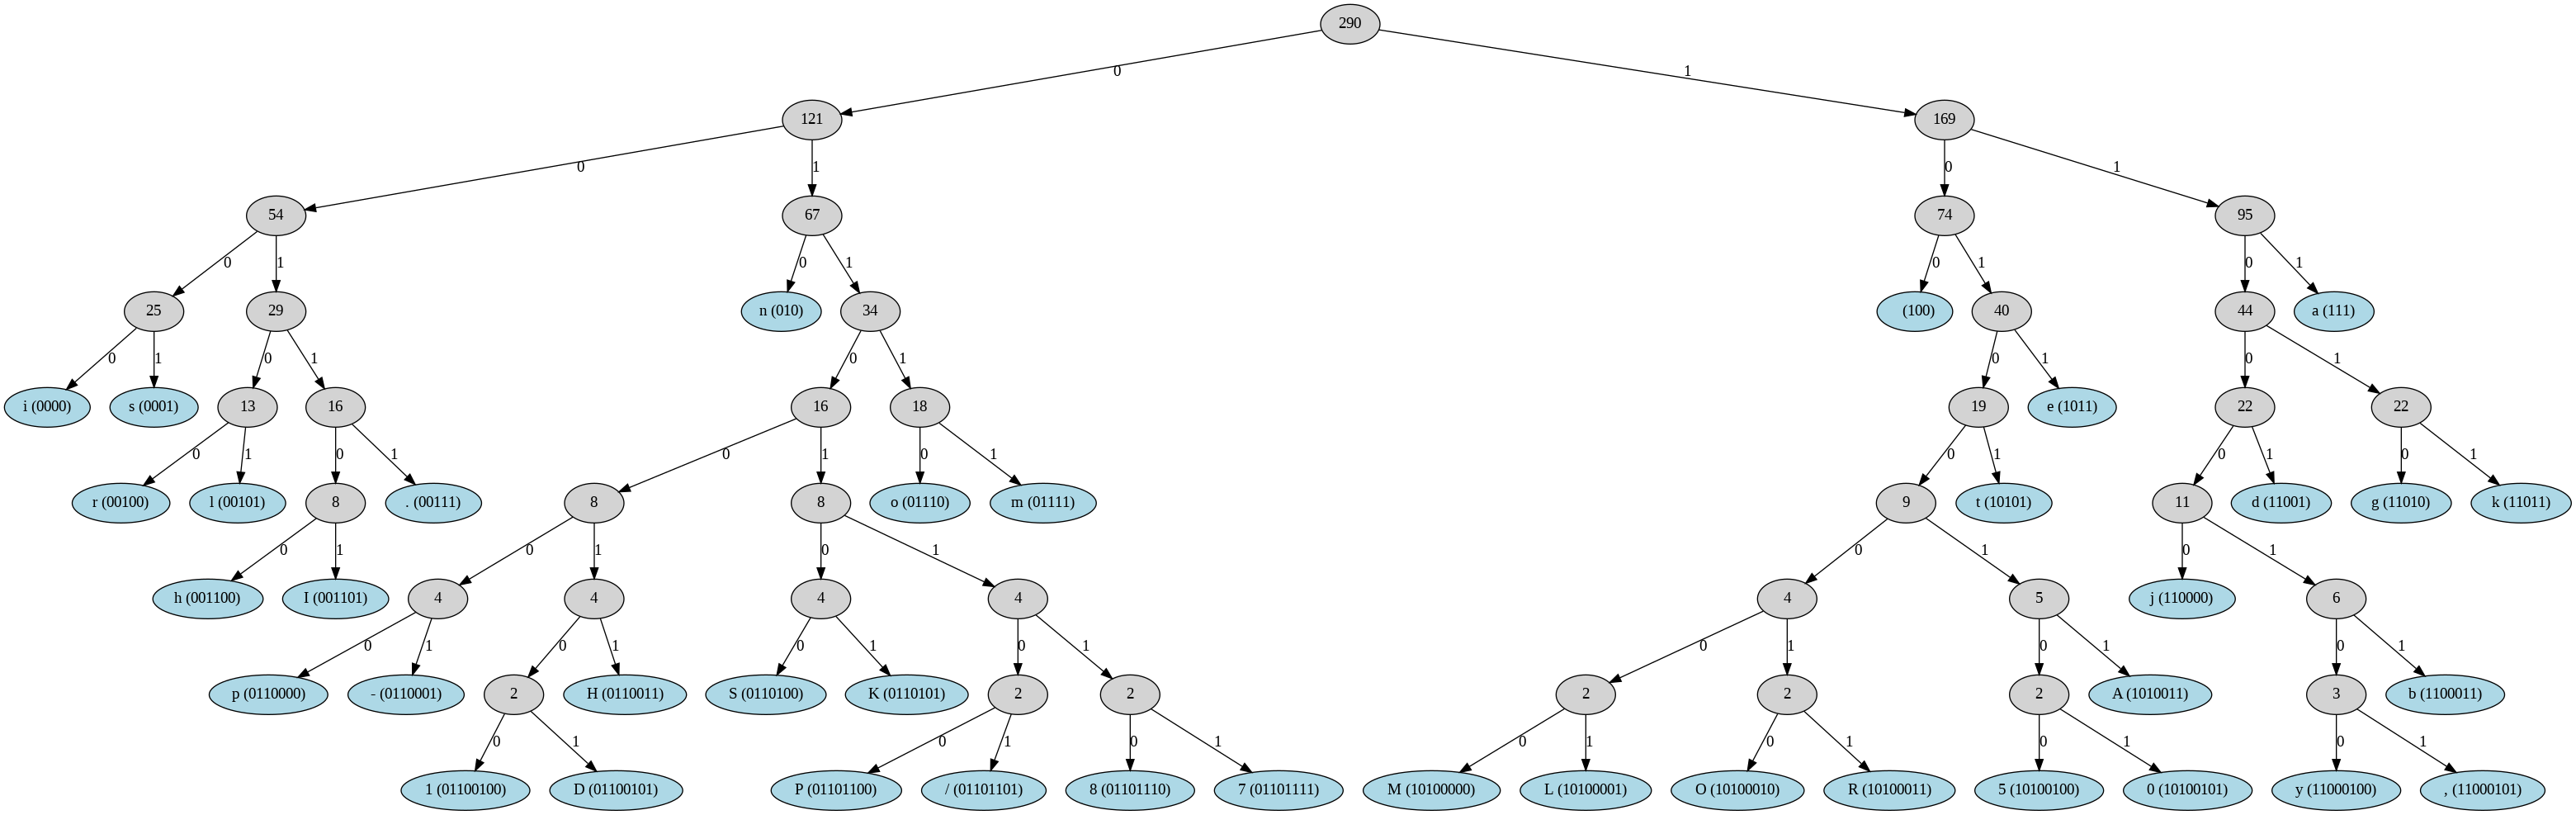

In [88]:
from graphviz import Digraph

def visualize_huffman_tree(node, huffman_codes):
    dot = Digraph()
    count = [0]

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        node_id = str(count[0])
        count[0] += 1

        # Jika simpul adalah daun (mengandung karakter)
        if node.char:
            label = f"{node.char} ({huffman_codes[node.char]})"
            color = "lightblue"  # Warna khusus untuk daun
        else:
            label = f"{node.freq}"
            color = "lightgray"  # Warna khusus untuk simpul internal

        dot.node(node_id, label, style="filled", fillcolor=color, shape="ellipse")

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.left:
            add_nodes_edges(node.left, node_id, "0")
        if node.right:
            add_nodes_edges(node.right, node_id, "1")

    add_nodes_edges(node)
    return dot

# Buat visualisasi pohon Huffman dengan kode Huffman ditampilkan di simpul daun
visual_tree = visualize_huffman_tree(tree, huffman_codes)
visual_tree.render("huffman_tree_modified", format="png", cleanup=True)

# Tampilkan gambar hasil render
from IPython.display import Image
Image("huffman_tree_modified.png")

# Kesimpulan Tugas

**Eksperimen 1: Bandingkan Rasio Kompresi**

Eksperimen ini membandingkan efisiensi kompresi Huffman Coding pada tiga tipe teks:

1. **Teks dengan banyak karakter unik (karakter acak dan simbolik)**:

   * Contoh teks dimodifikasi dari teks Proklamasi dengan penggantian huruf ke angka dan simbol (e.g., `4` untuk `A`, `@` untuk `a`).
   * Frekuensi karakter menjadi lebih merata, sehingga panjang kode Huffman mendekati seragam.
   * Hasil: **rasio kompresi rendah**, karena tidak banyak simbol yang bisa diberi kode pendek akibat distribusi frekuensi yang rata.

2. **Teks dengan karakter berulang**:

   * Frekuensi karakter sangat tidak merata, sehingga algoritma Huffman memberi kode sangat pendek untuk karakter yang sering muncul.
   * Hasil: **rasio kompresi tinggi**, karena skema pengkodean sangat efisien pada distribusi frekuensi ekstrem.

3. **Distribusi seragam vs tidak seragam**:

   * Distribusi frekuensi karakter sangat memengaruhi efisiensi Huffman Coding.
   * Teks dengan distribusi **tidak seragam (berat sebelah)** cenderung lebih **terkompres dengan baik**, sedangkan distribusi seragam membuat Huffman Coding kurang efektif.

**Kesimpulan Eksperimen 1**:

Efektivitas Huffman Coding sangat tergantung pada struktur distribusi karakter. Semakin tidak merata (semakin tinggi frekuensi karakter dominan), semakin efisien hasil kompresi.

**Eksperimen 2: Modifikasi Jumlah Karakter**

Eksperimen ini mengamati perubahan struktur pohon Huffman dan hasil kompresi setelah:

* **Menghapus beberapa karakter dari teks**:

  * Hasil: struktur pohon menyederhana, beberapa node hilang dari pohon dan skema pengkodean berubah.
  * Efisiensi kompresi bisa meningkat jika karakter yang dihapus merupakan karakter yang jarang muncul.

* **Menambahkan karakter baru**:

  * Hasil: menambah kedalaman pohon dan panjang kode secara umum meningkat, terutama jika karakter baru tidak dominan.
  * Efisiensi menurun jika karakter yang ditambahkan jarang muncul, karena hanya menambah panjang kode tanpa kontribusi besar terhadap pengurangan bit.

**Kesimpulan Eksperimen 2**:

Penambahan atau pengurangan karakter memengaruhi struktur pohon Huffman dan efisiensi kompresi. Karakter dominan memperpendek kode, sedangkan karakter langka justru bisa menurunkan efisiensi.

**Eksperimen 3: Validasi Konsistensi Decoding**

* Eksperimen ini menguji **ketahanan decoding** terhadap kesalahan satu bit pada hasil kompresi.
* Satu bit acak diubah pada string hasil kompresi, lalu dicoba didekode kembali menggunakan pohon Huffman.
* Hasil: proses decoding gagal menghasilkan teks asli atau berhenti di tengah jalan karena struktur Huffman tidak toleran terhadap error bit tunggal.

 **Kesimpulan Eksperimen 3**:

Huffman Coding **tidak robust terhadap error**. Perubahan satu bit saja bisa menyebabkan decoding menjadi tidak valid. Ini menunjukkan kebutuhan untuk metode tambahan seperti checksum atau ECC (error correction code) jika Huffman digunakan dalam kanal transmisi bising.

**Eksperimen 4: Visualisasi Perubahan**

* Pohon Huffman divisualisasikan dengan:

  * **Perbedaan warna antara daun dan simpul internal**.
  * **Label langsung kode Huffman pada setiap simpul daun**.
* Visualisasi ini mempermudah pemahaman struktur pohon, urutan prioritas karakter, dan kedalaman kode tiap karakter.

**Kesimpulan Eksperimen 4**:

Visualisasi yang informatif sangat membantu dalam menganalisis efektivitas dan distribusi kode dalam Huffman Coding. Ini juga memperjelas hubungan antara frekuensi karakter dan panjang kode yang diberikan.

**Kesimpulan Umum**

Eksperimen menunjukkan bahwa **Huffman Coding sangat efektif** untuk kompresi teks yang memiliki **distribusi frekuensi karakter tidak merata**. Namun, ia memiliki **keterbatasan dalam hal robustitas** terhadap error bit dan kurang efisien jika semua karakter memiliki frekuensi hampir sama. Visualisasi dan manipulasi karakter membantu memperdalam pemahaman akan perilaku algoritma ini dalam konteks kompresi teks nyata.
